# Fundamentos de Ciencia de Datos - FCEx - UNICEN

# Unidad 4: Visualización de datos

## Clase Práctica 5: Visualización de datos

Este Colab corresponde a la quinta clase práctica del curso Fundamentos de Ciencia de Datos, que se dicta en el 4to año de la carrera de Ingeniería de Sistemas de la Facultad de Ciencias Exactas de la UNICEN.

La clase de hoy es una introducción a la visualización de datos usando Python. A lo largo de ella vas a aprender cómo usar Matplotlib y Seaborn para generar algunas de las gráficas que (se supone) ya conocen de Probabilidad y Estadística. Si no se las acuerdan, vamos a hacer un repaso rápido, pero les sugerimos que vuelvan a sus apuntes a repasar!


## 0 - Descarguemos algunos datos para trabajar en la clase de hoy

Hoy no vamos a trabajar con un solo conjunto, si no con varios. No vamos a preprocesarlos ni analizar valores faltantes como hicimos la clase pasada, porque son datos que sabemos vienen curados. Pero lo ideal siempre es estudiarlos, primero, corregir esos problemas, y después empezar el análisis exploratorio, incluyendo las técnicas de análisis uni y bivariado que vimos en las clases anteriores, combinadas con las herramientas de visualización que vamos a ver hoy.

En el código de acá abajo hacemos la descarga inicial del conjunto.

In [ ]:
# instalamos el paquete para descargar archivos wget
!pip install wget

# importamos wget y las librerías que nos faltan
from wget import download
from os import path
import pandas as pd


# bajamos las casas
if not path.exists("housing_pandas.csv"):
  download("https://ignaciorlando.github.io/datasets/housing_pandas.csv")
else:
  print("No vamos a bajar el archivo de casas porque ya existe!")
# abrimos el archivo usando una función específica de pandas
raw_dataset_houses = pd.read_csv("housing_pandas.csv")
# cambiamos a CHAS para que sea booleano
raw_dataset_houses["CHAS"] = raw_dataset_houses["CHAS"].astype(bool)
# cambiamos las columnas que son porcentajes
raw_dataset_houses["ZN"] = raw_dataset_houses["ZN"] / 100
raw_dataset_houses["INDUS"] = raw_dataset_houses["INDUS"] / 100
raw_dataset_houses["AGE"] = raw_dataset_houses["AGE"] / 100
raw_dataset_houses["LSTAT"] = raw_dataset_houses["LSTAT"] / 100

# bajamos las tendencias históricas de PBI
if not path.exists("pib_per_capita_historico_cambio_1820.csv"):
  download("https://raw.githubusercontent.com/argendata/data/main/CRECIM/pib_per_capita_historico_cambio_1820.csv")
else:
  print("No vamos a bajar el archivo del PIB per capita histórico porque ya existe!")

# bajamos el conjunto de performance de estudiantes
if not path.exists("StudentPerformanceFactors.csv"):
  download("https://ignaciorlando.github.io/datasets/data-science/StudentPerformanceFactors.csv")
else:
  print("No vamos a bajar el archivo de performance porque ya existe!")

No vamos a bajar el archivo de casas porque ya existe!
No vamos a bajar el archivo del PIB per capita histórico porque ya existe!
No vamos a bajar el archivo de performance porque ya existe!


## 1 - Gráficos de líneas (line plots)

Los gráficos de líneas son un clásico que nunca falla. Los vemos constantemente en un montón de lugares, y representan una línea que va subiendo y bajando en un plano, mostrando cómo cambia una determinada variable en función de otra. Normalmente, la variable independiente (la que va en el eje X) suele estar de alguna forma vinculada con el tiempo: pueden ser días, fechas, años, segundos, o incluso iteraciones de un algoritmo.

¿Para qué sirven? Bueno, son la posta cuando querés mostrar tendencias o patrones a lo largo de un determinado período, porque trazan el camino de cómo van evolucionando. Algunos ejemplos de los usos más comunes:
- En economía: Para ver cómo evoluciona la inflación mes a mes, por ejemplo, o cómo evoluciona el PBI año tras año.
- En el clima: Para mostrar cómo cambia la temperatura a lo largo del día o las precipitaciones durante el año.
- En redes sociales: Para analizar cómo crece la cantidad de seguidores de tu cuenta de Instagram (sí, incluso los de la tuya, Mabel, que hace 2 años que tenés 27 followers nomás).
- En salud: Para seguir el progreso de un paciente, como el peso de alguien que está a dieta.
- En ventas: Para ver cómo vienen los números de tu negocio a lo largo del tiempo.

Acá abajo les dejo un ejemplo de cómo generar un gráfico de líneas usando Matplotlib. En este caso vamos a gráficar la evolución del PBI per capita de Argentina a lo largo del tiempo:

     geocodigoFundar      geonombreFundar  anio  pib_per_capita  \
0                DEU             Alemania  1820      2041.11409   
1                DEU             Alemania  1821      2060.62799   
2                DEU             Alemania  1822      2045.65125   
3                DEU             Alemania  1823      2028.86983   
4                DEU             Alemania  1824      2135.24329   
...              ...                  ...   ...             ...   
7788         SSA_MPD  África Subsahariana  2018      3480.80828   
7789         SSA_MPD  África Subsahariana  2019      3488.15526   
7790         SSA_MPD  África Subsahariana  2020      3335.98717   
7791         SSA_MPD  África Subsahariana  2021      3398.57848   
7792         SSA_MPD  África Subsahariana  2022      3436.59571   

      cambio_relativo  
0             0.00000  
1             0.00956  
2             0.00222  
3            -0.00600  
4             0.04612  
...               ...  
7788          1.92997  
778

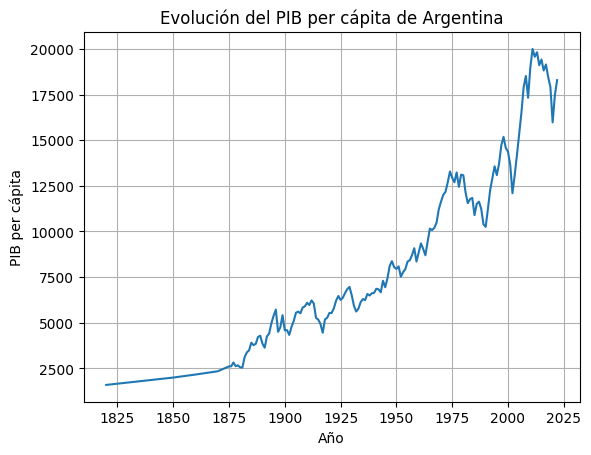

In [ ]:


import matplotlib.pyplot as plt

# Abrir el conjunto
dataset_pbi = pd.read_csv("pib_per_capita_historico_cambio_1820.csv")
print(dataset_pbi)

# Filtrar los datos para Argentina
argentina_data = dataset_pbi[dataset_pbi["geonombreFundar"] == "Argentina"]

# Crear el gráfico de líneas
plt.plot(argentina_data["anio"], argentina_data["pib_per_capita"])

# Agregar etiquetas a los ejes
plt.xlabel("Año")
plt.ylabel("PIB per cápita")

# Agregar un título al gráfico
plt.title("Evolución del PIB per cápita de Argentina")
plt.grid(True)

# Mostrar el gráfico
plt.show()


Fíjense que podemos ver las diferentes fluctuaciones en el tiempo producto de las sucesivas crisis económicas. A veces, cuando queremos comunicar un poco mejor y que se vean con más claridad esos hechos, podemos usar líneas verticales que los indiquen. Por ejemplo, podríamos marcar golpes de Estado como la Revolución Libertadora (1955), el golpe cívico-militar de 1976, la crisis financiera del 2001 y la pandemia.

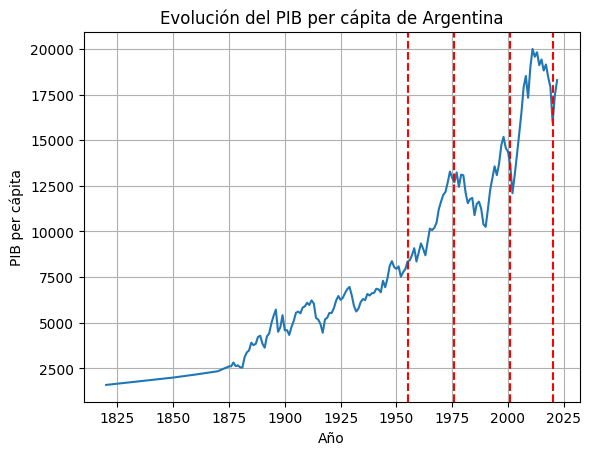

In [ ]:
# Crear el gráfico de líneas
plt.plot(argentina_data["anio"], argentina_data["pib_per_capita"])
# Agregar etiquetas a los ejes
plt.xlabel("Año")
plt.ylabel("PIB per cápita")
# Agregar un título al gráfico
plt.title("Evolución del PIB per cápita de Argentina")
plt.grid(True)

# Agregar líneas verticales
plt.axvline(x=1955, color='r', linestyle='--')
plt.axvline(x=1976, color='r', linestyle='--')
plt.axvline(x=2001, color='r', linestyle='--')
plt.axvline(x=2020, color='r', linestyle='--')

# Mostrar el gráfico
plt.show()


También podemos usar este tipo de gráfica para comparar series. En este caso usamos solamente a Argentina, pero podríamos por ejemplo sacar los datos de Brasil, y comparar entre sí la evolución de ambos PIB per cápita:

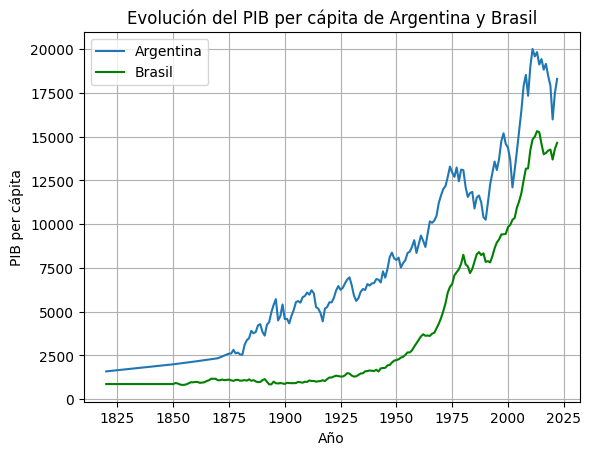

In [ ]:
import matplotlib.pyplot as plt

# Filtrar los datos para Argentina y Brasil
argentina_data = dataset_pbi[dataset_pbi["geonombreFundar"] == "Argentina"]
brasil_data = dataset_pbi[dataset_pbi["geonombreFundar"] == "Brasil"]

# Crear el gráfico de líneas
plt.plot(argentina_data["anio"], argentina_data["pib_per_capita"], label="Argentina")
plt.plot(brasil_data["anio"], brasil_data["pib_per_capita"], label="Brasil", color="green")

# Agregar etiquetas a los ejes
plt.xlabel("Año")
plt.ylabel("PIB per cápita")

# Agregar un título al gráfico
plt.title("Evolución del PIB per cápita de Argentina y Brasil")
plt.grid(True)

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()


En estos casos, fíjense que necesitamos sí o sí diferenciarlos a través del color, y representar qué indica cada color utilizando una leyenda. La leyenda además puede posicionarse en donde nosotros querramos, simplemente pasando un parámetro ```location``` al llamar a la rutina.

## 2 - Gráficos de barra (bar charts)

Los gráficos de barra son una herramienta re útil para visualizar datos, porque nos permiten observar variaciones de un valor según una cierta categoría, de forma rápida y clara. Son fáciles de entender y te permiten comparar información entre diferentes grupos o categorías de un saque, ganando visibilidad sobre las diferencias entre categorías de forma muy visual.

Para armarlos, necesitamos recordar que cada barra representa una categoría, y su altura (o longitud, si las ponés horizontales) va a corresponder al valor asociado a esa categoría. Cuanto más alta la barra, mayor el valor.

Podríamos, por ejemplo, usar un gráfico de barras para comparar el PIB per capita de todos los países latinoaméricanos, en el año 2021:

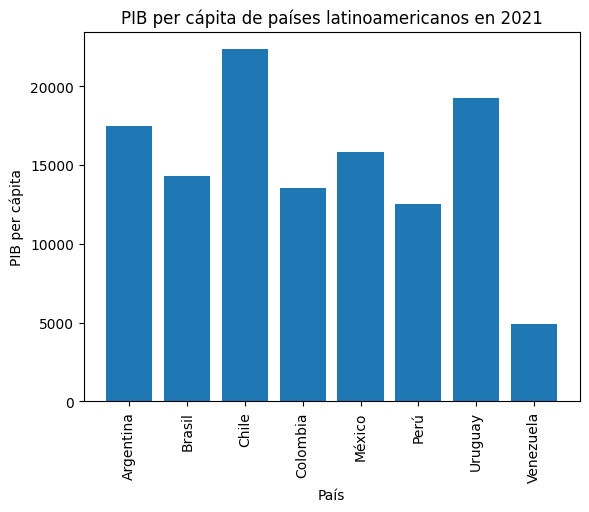

In [ ]:
import matplotlib.pyplot as plt

latinoamericanos = ["Argentina", "Brasil", "Chile", "Colombia", "México", "Perú", "Uruguay", "Venezuela"]
año = 2021

# Filtrar los datos para Latinoamérica en el año 2021
latam_data_2021 = dataset_pbi[(dataset_pbi["geonombreFundar"].isin(latinoamericanos)) & (dataset_pbi["anio"] == año)]

# Crear el gráfico de barras
plt.bar(latam_data_2021["geonombreFundar"], latam_data_2021["pib_per_capita"])

# Agregar etiquetas a los ejes
plt.xlabel("País")
plt.ylabel("PIB per cápita")

# Agregar un título al gráfico
plt.title(f"PIB per cápita de países latinoamericanos en {año}")
plt.xticks(rotation=90)  # Rotar las etiquetas del eje x para mejor visualización

# Mostrar el gráfico
plt.show()

Pero ojo, presentar los gráficos así no necesariamente tiene una utilidad. Necesitamos ponerles onda!

Por ejemplo, si quisiéramos entender qué países están mejor posicionados en materia de PBI per capita en este caso, se haría muy difícil hacerlo desde la visualización. Lo resolvemos muy fácil ordenando los datos antes.

De igual forma, si nuestro objetivo es referenciar cómo está posicionada Argentina en relación a otros países, podríamos diferenciar esa barra con otro color. Y, si elegimos colores, siempre está bueno usar los que más o menos se referencian con el elemento que queremos representar (o que, al menos, guarden relación con el concepto que estamos queriendo ilustrar). Si es algo bueno, usemos tonos asociados a lo positivo (verde, azul); si es algo malo, usemos el rojo o el naranja.

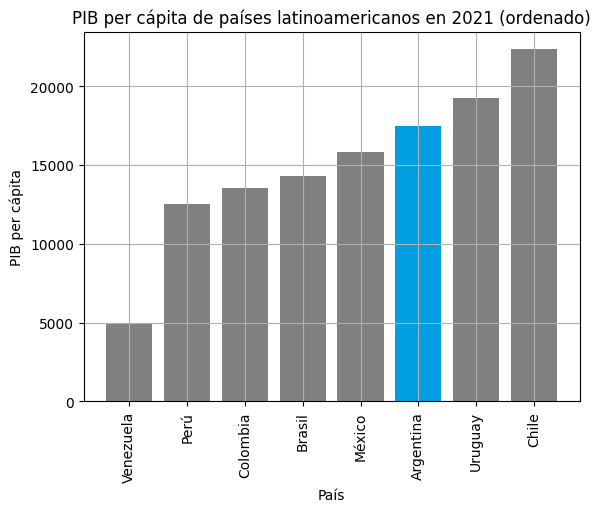

In [ ]:
# Ordenar los datos por PIB per capita
latam_data_2021 = latam_data_2021.sort_values(by="pib_per_capita")

# Crear el gráfico de barras
colors = ['#009FE4' if pais == "Argentina" else 'gray' for pais in latam_data_2021["geonombreFundar"]]
plt.bar(latam_data_2021["geonombreFundar"], latam_data_2021["pib_per_capita"], color=colors)

# Agregar etiquetas a los ejes
plt.xlabel("País")
plt.ylabel("PIB per cápita")

# Agregar un título al gráfico
plt.title("PIB per cápita de países latinoamericanos en 2021 (ordenado)")
plt.xticks(rotation=90)  # Rotar las etiquetas del eje x para mejor visualización
plt.grid(True)

# Mostrar el gráfico
plt.show()


Cuando queremos mostrar diferentes series de datos provenientes de una misma categoría (por ejemplo, para ilustrar las diferencias en el PIB per cápita entre 2020 y 2021, en este caso), podemos representar más de una barra por categoría. En ese caso, es importante recordar usar colores que discriminen bien ambas series, usando los más fuertes para la serie que más nos interesa destacar.

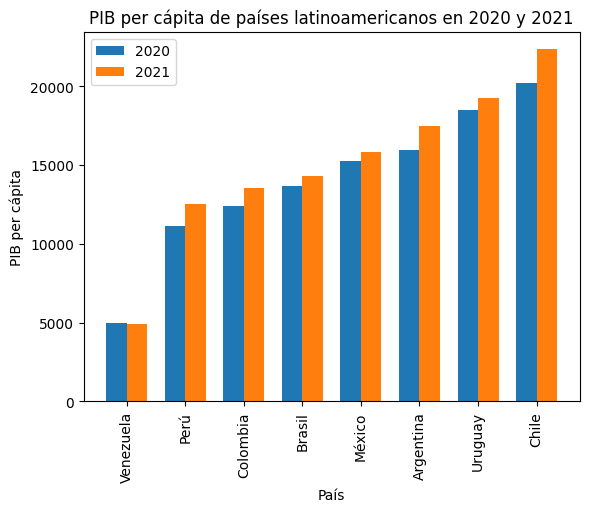

In [ ]:
latinoamericanos = ["Argentina", "Brasil", "Chile", "Colombia", "México", "Perú", "Uruguay", "Venezuela"]
año_2020 = 2020
año_2021 = 2021

# Filtrar los datos para Latinoamérica en 2020 y 2021
latam_data_2020 = dataset_pbi[(dataset_pbi["geonombreFundar"].isin(latinoamericanos)) & (dataset_pbi["anio"] == año_2020)]
latam_data_2021 = dataset_pbi[(dataset_pbi["geonombreFundar"].isin(latinoamericanos)) & (dataset_pbi["anio"] == año_2021)]
# Combinar los datos de 2020 y 2021
merged_data = latam_data_2021.merge(latam_data_2020, on="geonombreFundar", suffixes=('_2021', '_2020'))
# Ordenar los datos por PIB en 2021
merged_data = merged_data.sort_values(by="pib_per_capita_2021")

# Crear el gráfico de barras
x = merged_data["geonombreFundar"]
width = 0.35
plt.bar([i - width/2 for i in range(len(x))], merged_data["pib_per_capita_2020"], width, label='2020')
plt.bar([i + width/2 for i in range(len(x))], merged_data["pib_per_capita_2021"], width, label='2021')

# Agregar etiquetas a los ejes
plt.xlabel("País")
plt.ylabel("PIB per cápita")

# Agregar un título al gráfico
plt.title("PIB per cápita de países latinoamericanos en 2020 y 2021")
plt.xticks(range(len(x)), merged_data["geonombreFundar"], rotation=90)  # Rotar las etiquetas del eje x para mejor visualización

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()


## 3 - Gráfico de torta (pie chart)

Los gráficos de torta o circulares también son bastante famosos. Los usamos cuando queremos mostrar qué proporciones de un todo corresponden a determinadas partes. La idea es re sencilla: tomamos un círculo ("la torta"), y la dividimos en porciones, donde cada porción cubre un ángulo que se asocia proporcionalmente con la cantidad correspondiente a esa categoría.

Es una forma muy visual y efectiva de entender proporciones, y son útiles para mostrar porcentajes de un total (por ejemplo, cuántas muestras tienen cada valor posible de una variable cualitativa), la composición de algo (por ejemplo, cuántos ml de una sustancia química corresponden a tal o cuáles ingredientes), o cómo se distribuye un recurso (por ejemplo, qué proporción del PIB latinoamericano le corresponde a cada país de Latinoamérica).

Acá por ejemplo les muestro qué proporción del total de muestras del conjunto de datos de Boston tiene la variable "CHAS" en True (es decir, limitan con el río Charles).

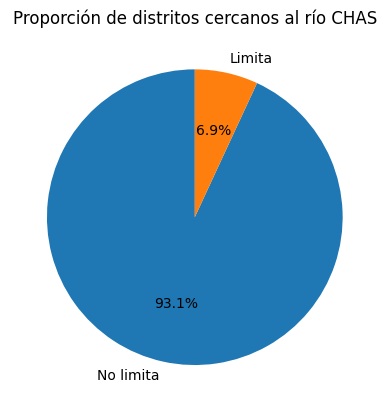

In [ ]:
# Contar la cantidad de distritos con CHAS=True y CHAS=False
chas_counts = raw_dataset_houses["CHAS"].value_counts()

# Crear el gráfico de torta
labels = ["No limita" if label == False else "Limita" for label in chas_counts.index]
plt.pie(chas_counts, labels=labels, autopct='%1.1f%%', startangle=90)

# Agregar un título al gráfico
plt.title("Proporción de distritos cercanos al río CHAS")

# Mostrar el gráfico
plt.show()


No hay mucho más para elaborar de un gráfico así, más que recordar que son efectivos para visualizar datos que no tienen demasiadas categorías. No tiene ningún sentido recurrir a un gráfico así en casos en los que la cantidad de categorías es muy alta, porque se diluyen las diferentes porciones y es muy difícil de interpretar.

## 4 - Histogramas (histograms)

Los histogramas son clave para entender la distribución de datos numéricos. A diferencia de otros gráficos, los histogramas agrupan datos en baldes o "bins", cada uno de los cuales representa un rango. Así, a cada rango se le asigna la frecuencia (absoluta o relativa, según nos interese) de valores que caen dentro de cada rango.

Son geniales para ver la forma de una distribución: si es simétrica, sesgada, tiene varios picos o uno solo. Lo interesante es que revelan patrones que podrían pasar desapercibidos en datos crudos. Te permiten identificar rápidamente dónde se concentran la mayoría de los valores, si hay valores atípicos o gaps en los datos.

Un consejo: jugá con el número de bins. Menos bins te dan una visión más general, más bins pueden mostrar detalles sutiles. No hay una regla fija, así que experimentá hasta encontrar la visualización que mejor cuente tu historia de datos.

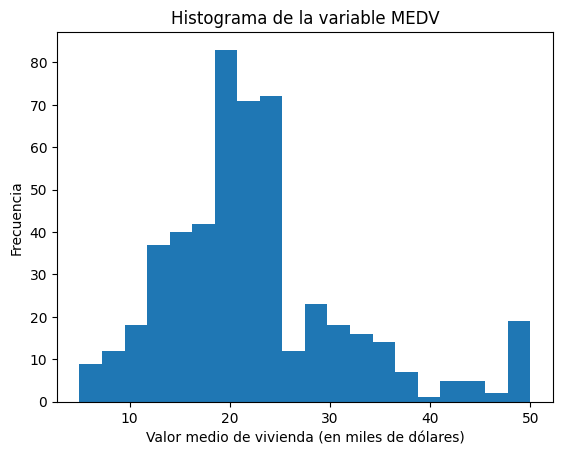

In [ ]:
#bins=5
#bins=10
bins=20

# Crear el histograma
plt.hist(raw_dataset_houses["MEDV"], bins=bins)

# Agregar etiquetas a los ejes
plt.xlabel("Valor medio de vivienda (en miles de dólares)")
plt.ylabel("Frecuencia")

# Agregar un título al gráfico
plt.title("Histograma de la variable MEDV")

# Mostrar el gráfico
plt.show()


También podemos usar los métodos que vienen por defecto en la clase ```DataFrame``` de Pandas. Internamente usan Matplotlib, así que no esperes encontrarte con algo muy distinto (pero es bastante cómodo):

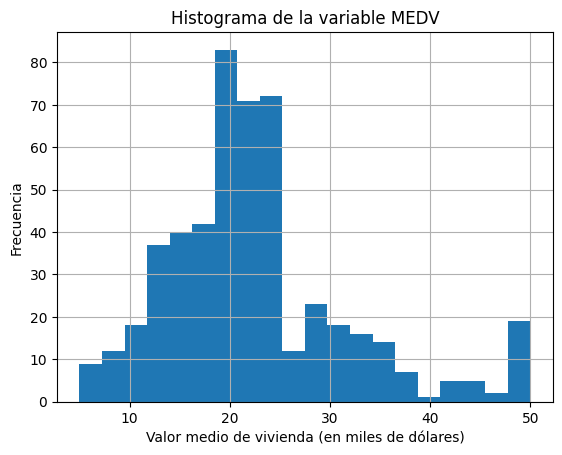

In [ ]:
# Crear el histograma
raw_dataset_houses["MEDV"].hist(bins=bins)

# Agregar etiquetas a los ejes
plt.xlabel("Valor medio de vivienda (en miles de dólares)")
plt.ylabel("Frecuencia")

# Agregar un título al gráfico
plt.title("Histograma de la variable MEDV")

# Mostrar el gráfico
plt.show()


Si queremos ver todos los histogramas a la vez, podemos usar ese mismo método, pero aplicándolo sobre todas las columnas, sin separarlas. Por si queremos refrescar qué representa cada columna, les dejo acá lo que representa cada columna:


    - CRIM     tasa de criminalidad per cápita por distrito
    - ZN       proporción de terrenos residenciales zonificados para lotes de más de 25,000 pies cuadrados.
    - INDUS    proporción de acres de negocios no minoristas por municipio.
    - CHAS     límite con el río Charles (= 1 si limita; 0 si no)
    - NOX      concentración de óxido nítrico (partes por 10 millones)
    - RM       cantidad promedio de habitaciones por vivienda
    - AGE      proporción de unidades ocupadas por sus propietarios construidas antes de 1940
    - DIS      distancias ponderadas a cinco centros de empleo de Boston
    - RAD      índice de accessibilidad a carreteras radiales
    - TAX      tasa de impuesto a la propiedad de valor total por U$D 10.000
    - PTRATIO  tasa alumno/profesor por localidad
    - B        1000(Bk - 0.63)^2, donde Bk es la proporción de habitantes de raza negra que viven en la zona
    - LSTAT    % de habitantes de clase social baja
    - MEDV     Valor medio de vivienda (en miles de dólares)


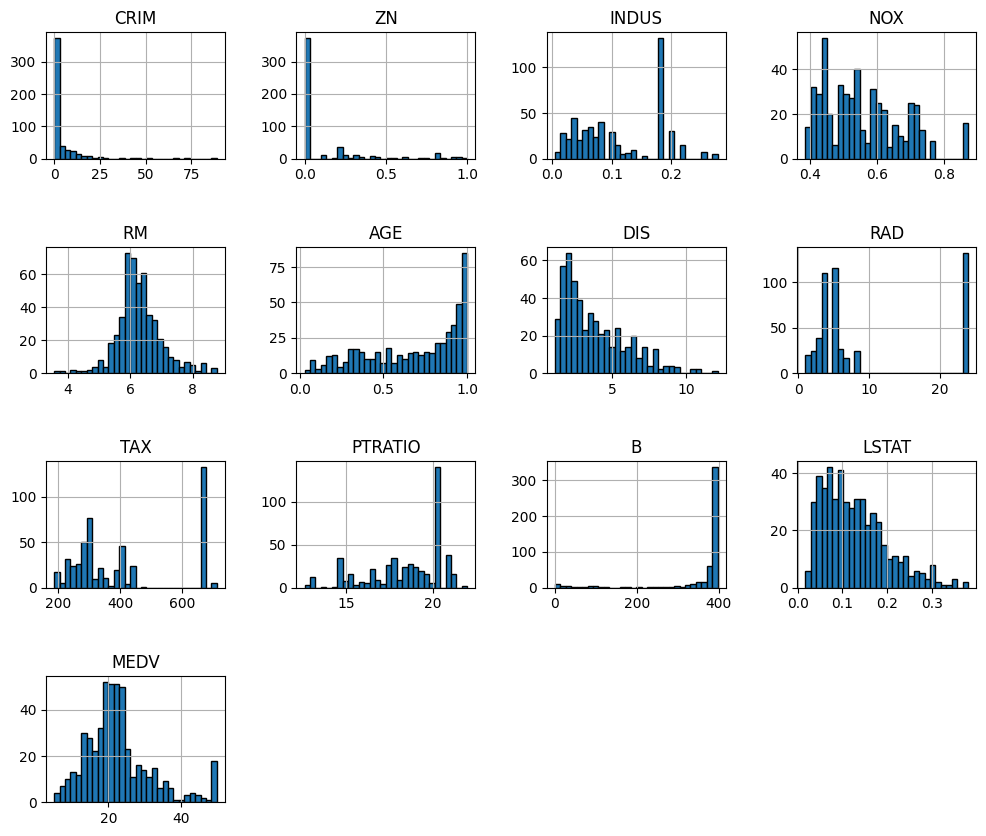

In [ ]:
# construimos una serie de histogramas mostrando la distribución de las features
raw_dataset_houses.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

## 5 - Gráficos de dispersión (scatter plots)

Ya venimos trabajando con varios diagramas de dispersión, pero vamos a aprovechar para recordar algunas cuestiones en torno a ellos.

Para empezar, recordemos que son útiles para hacer análisis bivariado, porque nos permiten estudiar la relación entre dos variables cuantitativas. Podemos usarlo con cualitativas (preprocesadas, claro), pero no son el gráfico ideal para presentar ese tipo de relaciones (así como la correlación entre dos variables cualitativas no es correcta como modo de análisis).

En cualquier scatter plot, siempre tratemos de representar los ejes cuadrados y de cubrir todo el rango teórico de una variable, para que la escala sea consistente y no sesgar los análisis. Si no conocemos el rango teórico no pasa nada, pero si lo conocemos, está bueno tenerlo en cuenta.

En ese caso analizaremos la relación entre el número de ambientes promedio de las casas de un distrito, y las medianas en miles de dólares de esas casas.




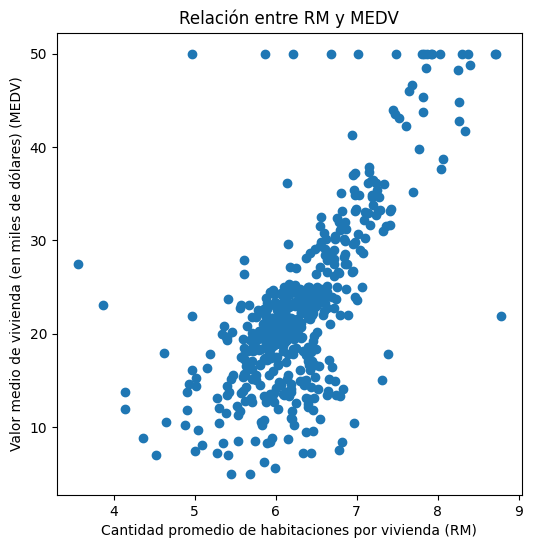

In [ ]:
# Crear el gráfico de dispersión
plt.figure(figsize=(6, 6))  # Hacer el gráfico cuadrado
plt.scatter(raw_dataset_houses["RM"], raw_dataset_houses["MEDV"])

# Agregar etiquetas a los ejes
plt.xlabel("Cantidad promedio de habitaciones por vivienda (RM)")
plt.ylabel("Valor medio de vivienda (en miles de dólares) (MEDV)")

# Agregar un título al gráfico
plt.title("Relación entre RM y MEDV")

# Mostrar el gráfico
plt.show()


Podríamos también estudiar los subgrupos correspondientes a los distritos vecinos al río Charles y los que no, usando esa categoría de agrupamiento y trabajando con distintos colores.

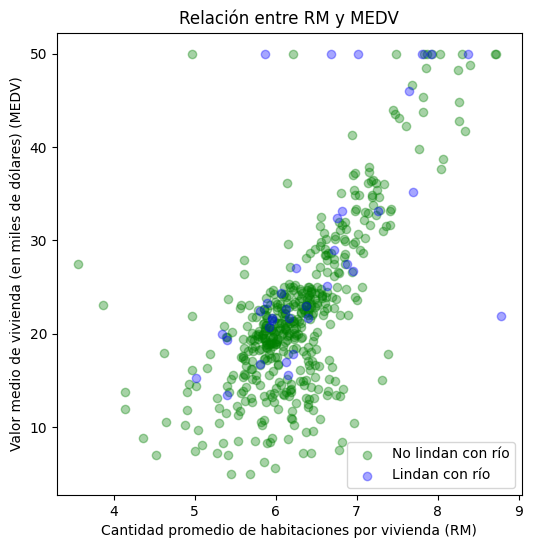

In [ ]:
# Crear el gráfico de dispersión
plt.figure(figsize=(6, 6))  # Hacer el gráfico cuadrado

# Filtrar los datos por CHAS
chas_false = raw_dataset_houses[raw_dataset_houses["CHAS"] == False]
chas_true = raw_dataset_houses[raw_dataset_houses["CHAS"] == True]

# Graficar los puntos con colores diferentes
plt.scatter(chas_false["RM"], chas_false["MEDV"], color="green", alpha=0.35, label="No lindan con río")
plt.scatter(chas_true["RM"], chas_true["MEDV"], color="blue", alpha=0.35, label="Lindan con río")

# Agregar etiquetas a los ejes
plt.xlabel("Cantidad promedio de habitaciones por vivienda (RM)")
plt.ylabel("Valor medio de vivienda (en miles de dólares) (MEDV)")

# Agregar un título al gráfico
plt.title("Relación entre RM y MEDV")

# Agregar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()


Pandas también nos provee la rutina scatter_matrix, para mostrar todos los posibles pares de scatter plots entre variables, e histogramas en la diagonal.

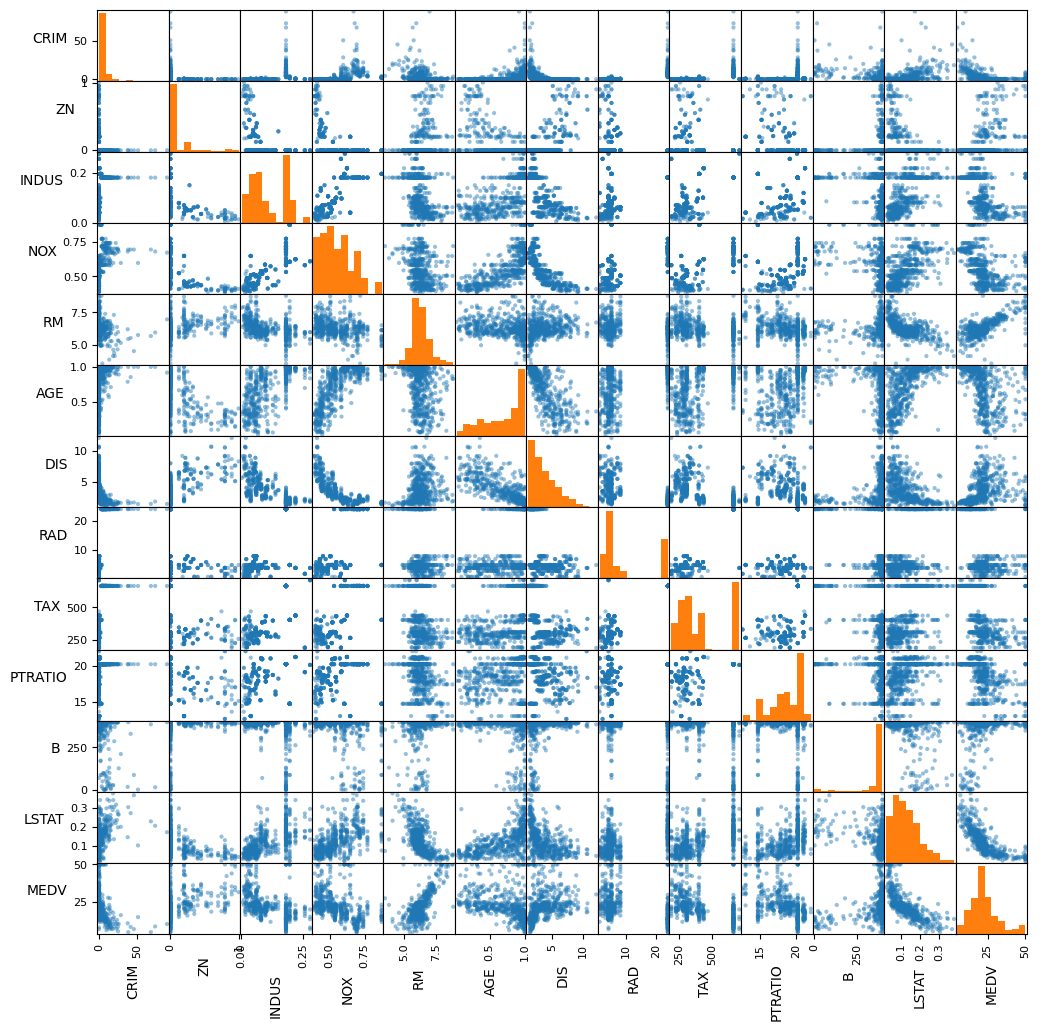

In [ ]:
# Seleccionar las columnas numéricas
numeric_cols = raw_dataset_houses.select_dtypes(include=['number'])

# Crear el scatter matrix
axs = pd.plotting.scatter_matrix(numeric_cols, figsize=(12, 12), alpha=0.47, hist_kwds={'color':'#ff7f0e'})
# la mostramos por pantalla
# acomodamos la orientación del contenido de los ejes
for i in range(len(numeric_cols.columns)):
  for j in range(len(numeric_cols.columns)):
    ax=axs[i,j]
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

Cambiamos el color de la diagonal para que se vea un poco mejor. Vemos que en la diagonal directamente tenemos representado el histograma con cómo se distribuyen las muestras en cada feature, y en los demás sectores tenemos un scatter plot contrastando una feature con otra.

## 6 - Diagrama de cajas "y bigotes" (boxplots)

El diagrama de cajas (a veces lo van a encontrar como diagrama de cajas y bigotes), comúnmente conocido como boxplot, es una herramienta estadística recontra útil, que representa gráficamente la distribución de un conjunto de datos numéricos. Este método de visualización, introducido por John Tukey en 1970, te resume gráficamente cinco estadísticas claves:
- El mínimo
- El primer cuartil (Q1)
- La mediana (segundo cuartil o Q2)
- El tercer cuartil (Q3)
- El máximo

La estructura del boxplot es sencilla. Para cada categoría o grupo que nos interesa analizar, tenemos una "caja" central que abarca desde el primer al tercer cuartil, con una línea que marca la mediana. Los "bigotes" (por eso el nombre) se extienden desde los bordes de la caja hasta los valores mínimo y máximo, excluyendo valores atípicos (esto es porque en lugar del mínimo y el máximo se representan relaciones entre los Q1 y Q3 y el rango intercuartil). Estos últimos, cuando están presentes, se representan como puntos individuales más allá de los bigotes.

![](https://www.laboneconsultoria.com.br/wp-content/uploads/2018/07/Boxplot-04.png)

(recuerden que $\text{IQR} = Q_3 - Q_1$)

El boxplot es particularmente útil para:
- Identificar la simetría o asimetría de la distribución (aunque para esto siempre es más recomendable el histograma)
- Detectar valores atípicos (los vas a ver como unos círculos por fuera del rango)
- Comparar distribuciones entre diferentes grupos o categorías (para observar tendencias tipo "este grupo es más alto/bajo que este otro")
- Visualizar la dispersión y la centralidad de los datos.

En el contexto del análisis exploratorio de datos, los boxplots permiten estudiar la estructura de los datos muy eficazmente. Es muy raro encontrarlo en la televisión o en visualizaciones para el público en general, pero se los usa muchísimo en textos estadísticos o en los que se espera que la audiencia sea experta.

Para ver al diagrama en acción, vamos a trabajar con un conjunto nuevo, de datos educativos:

In [ ]:
# Abrir el conjunto
dataset_estudiantes = pd.read_csv("StudentPerformanceFactors.csv")
# Mostrarlo
dataset_estudiantes.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


El primer boxplot que vamos a generar es para estudiar la relación entre la cantidad de horas que los alumnos estudian por semana, y el nivel de involucramiento de los padres en la educación de sus hijos. Uno a priori esperaría que, cuanto más los padres les estén encima, más tiempo ellos estén estudiando. Veamos si es tan así.

Para generar boxplots usando Matplotlib, tenemos que prefiltrar los datos nosotros, como a continuación:

/tmp/ipykernel_2828/2896809861.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dataset_estudiantes[dataset_estudiantes["Parental_Involvement"] == "Low"]["Hours_Studied"],


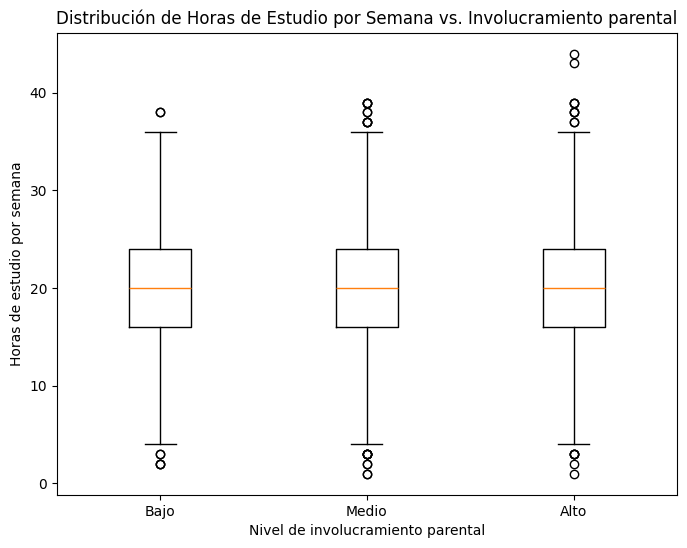

In [ ]:
import matplotlib.pyplot as plt

# Crear el boxplot
plt.figure(figsize=(8, 6))
plt.boxplot([dataset_estudiantes[dataset_estudiantes["Parental_Involvement"] == "Low"]["Hours_Studied"],
             dataset_estudiantes[dataset_estudiantes["Parental_Involvement"] == "Medium"]["Hours_Studied"],
             dataset_estudiantes[dataset_estudiantes["Parental_Involvement"] == "High"]["Hours_Studied"]],
             labels=["Bajo", "Medio", "Alto"])

# Agregar etiquetas a los ejes
plt.xlabel("Nivel de involucramiento parental")
plt.ylabel("Horas de estudio por semana")

# Agregar un título al gráfico
plt.title("Distribución de Horas de Estudio por Semana vs. Involucramiento parental")

# Mostrar el gráfico
plt.show()


Por el parecido que vemos entre las distribuciones, podemos concluir que no necesariamente el nivel de involucramiento de los padres guarda una relación con el tiempo en que los alumnos se la pasan estudiando.

Desde el punto de vista estético, este gráfico se parece bastante a cómo amanezco yo los domingos cuando tengo el pelo largo: feo feísimo. Tenemos que hacer algo para embellecerlo.

En Matplotlib es un bardo. Lo ideal es mudarnos a Seaborn, una librería genial muy integrada con Pandas, y que ofrece gráficos más sencillos de crear a partir de DataFrames. En este caso vamos a producir un boxplot equivalente al anterior.

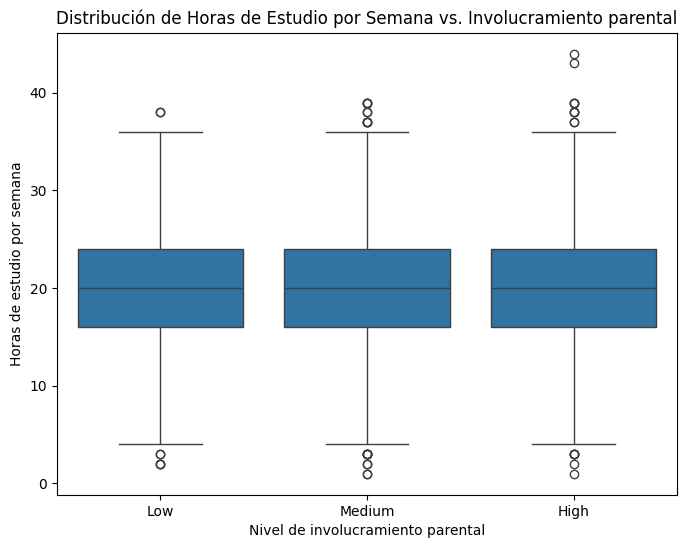

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el boxplot con Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x="Parental_Involvement", y="Hours_Studied", data=dataset_estudiantes)

# Agregar etiquetas a los ejes
plt.xlabel("Nivel de involucramiento parental")
plt.ylabel("Horas de estudio por semana")

# Agregar un título al gráfico
plt.title("Distribución de Horas de Estudio por Semana vs. Involucramiento parental")

# Mostrar el gráfico
plt.show()


La gráfica es similar, pero al menos ahora vemos algunos colores :)

Ahora, desde el punto de vista estadístico, no estamos viendo nada nuevo. Así que aprovechemos para meter otro concepto más: el de los notches, o hendiduras.

Los notches en un boxplot son hendiduras que se dibujan alrededor de la mediana de cada caja. Tienen el objetivo de brindar una referencia visual sobre la variabilidad de la mediana, es decir, sirven para estimar si las medianas de diferentes grupos son significativamente diferentes entre sí. Si los notches de dos boxplots no se superponen, eso sugiere que hay una diferencia estadísticamente significativa entre las medianas de esos grupos, al menos con un nivel de confianza del 95%.

![](https://i.sstatic.net/urPEC.jpg)

En términos técnicos, la amplitud del notch está relacionada con el rango intercuartílico (IQR) y el tamaño de la muestra. Sin embargo, es importante recordar que estos notches no son una prueba estadística definitiva, sino más bien una guía visual. Si vez que no hay overlap, lo ideal es tirarse algún test de hipótesis para terminar de ponerle un p-valor a esas diferencias.

En nuestro caso, veamos qué ocurre si agregamos notches:

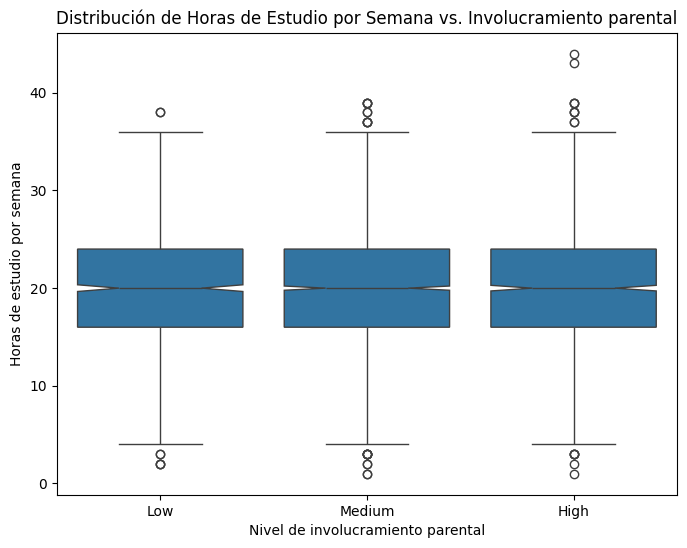

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Abrir el conjunto
dataset_estudiantes = pd.read_csv("StudentPerformanceFactors.csv")

# Crear el boxplot con Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x="Parental_Involvement", y="Hours_Studied", data=dataset_estudiantes, notch=True)

# Agregar etiquetas a los ejes
plt.xlabel("Nivel de involucramiento parental")
plt.ylabel("Horas de estudio por semana")

# Agregar un título al gráfico
plt.title("Distribución de Horas de Estudio por Semana vs. Involucramiento parental")

# Mostrar el gráfico
plt.show()


A simple vista vemos que hay bastante solapamiento entre estos acogotamiento, lo que nos da a pensar que, si le tiráramos un test de Wilcoxon, por ejemplo, no veríamos diferencias. ¿Lo hacemos? No, ni a ganchos, lo vamos a ver más adelante cuando veamos tests de hipótesis.

Ahora, veamos si hay alguna relación entre el nivel de involucramiento de los padres y la nota de un examen.

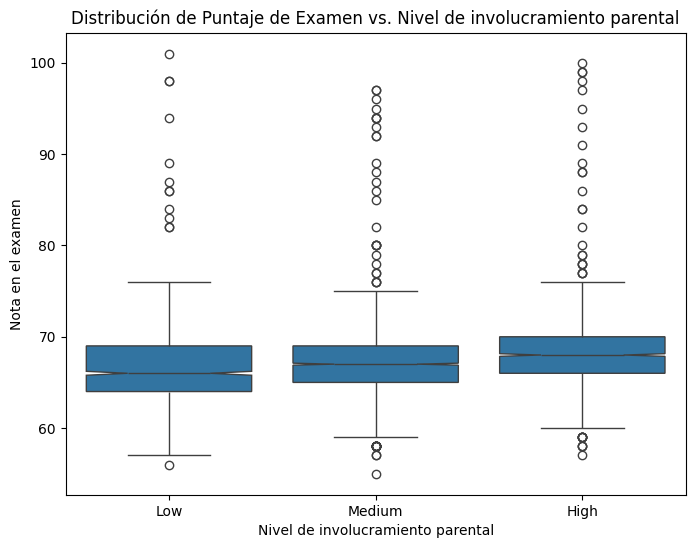

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el boxplot con Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=dataset_estudiantes, notch=True)

# Agregar etiquetas a los ejes
plt.xlabel("Nivel de involucramiento parental")
plt.ylabel("Nota en el examen")

# Agregar un título al gráfico
plt.title("Distribución de Puntaje de Examen vs. Nivel de involucramiento parental")

# Mostrar el gráfico
plt.show()


En este caso vemos que efectivamente no hay solapamiento entre los grupos, lo que a priori podría indicar que no existen diferencias signficiativas entre los grupos.

Antes de irnos, que no puedo con mi genio: corrijamos el eje y, que ya le conocemos el rango teórico (entre 0 y 100), y ahora está horrendo.

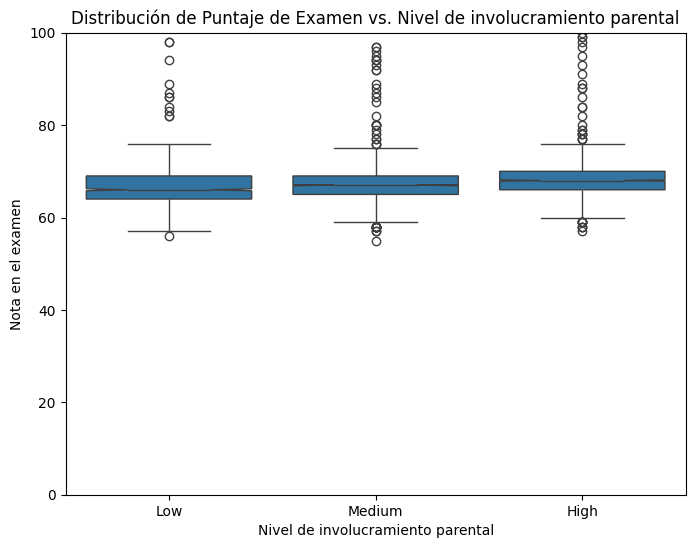

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear el boxplot con Seaborn
plt.figure(figsize=(8, 6))
sns.boxplot(x="Parental_Involvement", y="Exam_Score", data=dataset_estudiantes, notch=True)

# Agregar etiquetas a los ejes
plt.xlabel("Nivel de involucramiento parental")
plt.ylabel("Nota en el examen")

# Acomodamos el eje y
plt.ylim([0, 100])

# Agregar un título al gráfico
plt.title("Distribución de Puntaje de Examen vs. Nivel de involucramiento parental")

# Mostrar el gráfico
plt.show()


¿Y qué pasó ahora? Que los acogotamientos se nos amontonaron tanto que no vemos nada! Dependiendo de qué es lo que queremos mostrar (si las diferencias entre los grupos o cómo todas las notas están bastante arriba), iremos por tal o cual enfoque.

Bueno, nada. Estas gráficas son la base para que puedan desarrollar el práctico 5. Ya deberían poder avanzar y brillar, mis pequeñxs palomillas.

Importante. Quiero que LE PONGAN ONDA. Graficar es un arte, que se entrena haciendo muchas gráficas, y siendo retadx cada vez que lo hacés mal o no lo suficientemente bien. ¡Así que aprovechen para practicar! Y los dejo así me pego una ducha y hago la comida. 20:48, cada vez más al horno! XD